In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/anemia_detection/datasets')

['palpablepalm_dataset.zip',
 'fingernails_dataset.zip',
 'conjunctiva_dataset.zip']

In [ ]:
!unzip "/content/drive/MyDrive/anemia_detection/datasets/fingernails_dataset.zip"

Archive:  /content/drive/MyDrive/anemia_detection/datasets/fingernails_dataset.zip
  inflating: Detection of Anemia using Colour of the Fingernails Image Datasets from Ghana/Fingernails.rar  


In [ ]:
!unrar x "/content/Detection of Anemia using Colour of the Fingernails Image Datasets from Ghana/Fingernails.rar"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Detection of Anemia using Colour of the Fingernails Image Datasets from Ghana/Fingernails.rar

Creating    Fingernails                                               OK
Extracting  Fingernails/Anemic-Fin-007 (10).png                            0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (11).png                            0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (12).png                            0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (2).png                             0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (3).png                             0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (4).png                             0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (5).png                             0%  OK 
Extracting  Fingernails/Anemic-Fin-007 (6).png                             0% 

In [ ]:
import os

os.listdir('/content')
dataset_path = "/content/Fingernails"
from glob import glob

images = glob(dataset_path + "/*.png")

print("Toplam görüntü:", len(images))
print(images[:5])

Toplam görüntü: 4260
['/content/Fingernails/Anemic-FN-147 (5).png', '/content/Fingernails/Anemic-FN-058 (10).png', '/content/Fingernails/Anemic-Fin-016 (8).png', '/content/Fingernails/Non-Anrmic-FN-192 (3).png', '/content/Fingernails/Anemic-FN-030 (4).png']


In [ ]:
import os
from glob import glob

images = glob(dataset_path + "/*")

print("Toplam bulunan dosya:", len(images))
for x in images[:10]:
    print(repr(os.path.basename(x)))

Toplam bulunan dosya: 4260
'Anemic-FN-147 (5).png'
'Anemic-FN-058 (10).png'
'Anemic-Fin-016 (8).png'
'Non-Anrmic-FN-192 (3).png'
'Anemic-FN-030 (4).png'
'Anemic-FN-266 (4).png'
'Anemic-FN-194 (2).png'
'Anemic-FN-150 (5).png'
'Anemic-Fin-024 (6).png'
'Non-Anrmic-FN-020 (3).png'


In [ ]:
import os
import re
import pandas as pd
from glob import glob

files = glob(os.path.join(dataset_path, "*.png"))

def parse_filename(path):
    name = os.path.basename(path)
    stem = os.path.splitext(name)[0]

    # augmentation numarası
    aug_match = re.search(r"\((\d+)\)$", stem)
    if aug_match:
        aug_no = int(aug_match.group(1))
        stem_core = re.sub(r"\s*\(\d+\)$", "", stem)
    else:
        aug_no = 1
        stem_core = stem

    lower = stem_core.lower()

    # sınıf
    if lower.startswith("non-anemic"):
        cls = "Non-Anemic"
        rest = stem_core[len("Non-Anemic-"):] if stem_core.startswith("Non-Anemic-") else stem_core[len("Non-anemic-"):]
    elif lower.startswith("anemic"):
        cls = "Anemic"
        rest = stem_core[len("Anemic-"):]
    else:
        cls = "Unknown"
        rest = stem_core

    # subtype
    subtype = "base"
    if rest.endswith("FV"):
        subtype = "FV"
        rest = rest[:-2]
    elif rest.endswith("RA"):
        subtype = "RA"
        rest = rest[:-2]
    elif "Conj-" in rest:
        subtype = "Conj"
        rest = rest.replace("Conj-", "")
    elif "Con-" in rest:
        subtype = "Con"
        rest = rest.replace("Con-", "")

    # id yakala
    id_match = re.search(r"(\d+)", rest)
    sample_id = id_match.group(1) if id_match else None

    series_key = f"{cls}_{sample_id}_{subtype}"

    return {
        "filename": name,
        "class": cls,
        "sample_id": sample_id,
        "subtype": subtype,
        "aug_no": aug_no,
        "series_key": series_key,
        "path": path
    }

df = pd.DataFrame([parse_filename(f) for f in files])

print(df.head(20))
print("\nSubtype sayıları:")
print(df["subtype"].value_counts())

print("\nSeri sayıları:")
print(df["series_key"].nunique())

print("\nHer seride kaç görüntü var:")
print(df.groupby("series_key").size().value_counts().sort_index())

                      filename       class sample_id subtype  aug_no  \
0        Anemic-FN-147 (5).png      Anemic       147    base       5   
1       Anemic-FN-058 (10).png      Anemic       058    base      10   
2       Anemic-Fin-016 (8).png      Anemic       016    base       8   
3    Non-Anrmic-FN-192 (3).png     Unknown       192    base       3   
4        Anemic-FN-030 (4).png      Anemic       030    base       4   
5        Anemic-FN-266 (4).png      Anemic       266    base       4   
6        Anemic-FN-194 (2).png      Anemic       194    base       2   
7        Anemic-FN-150 (5).png      Anemic       150    base       5   
8       Anemic-Fin-024 (6).png      Anemic       024    base       6   
9    Non-Anrmic-FN-020 (3).png     Unknown       020    base       3   
10       Anemic-FN-153 (3).png      Anemic       153    base       3   
11   Non-Anrmic-FN-180 (3).png     Unknown       180    base       3   
12         Anmeic-fn-009 1.png     Unknown       009    base    

In [ ]:
anemic_count = (
    df["filename"].str.startswith("Anemic").sum()
    + df["filename"].str.startswith("Anmeic").sum()
)
non_anemic_count = (
    df["filename"].str.startswith("Non-Anemic").sum()
    + df["filename"].str.startswith("Non-Anrmic").sum()
    + df["filename"].str.startswith("Non-anemic").sum()
)

print("Anemic ile başlayan:", anemic_count)
print("Non-anemic ile başlayan:", non_anemic_count)
print("Toplam:", anemic_count + non_anemic_count)

Anemic ile başlayan: 2565
Non-anemic ile başlayan: 1695
Toplam: 4260


In [ ]:
# Tüm prefixler
prefixes = ["Anemic", "Non-Anemic", "Non-Anrmic", "Non-anemic"]

# Bu prefixlerle başlamayan dosyaları seç
other_files = df[~df["filename"].str.startswith(tuple(prefixes))]

# Kaç tane dosya var
print("Diğer dosya sayısı:", len(other_files))

# Dosya isimlerini görmek istersen
print(other_files["filename"].tolist())

Diğer dosya sayısı: 44
['Anmeic-fn-009 1.png', 'Anmeic-fn-002.png', 'Anmeic-fn-001.png', 'Anmeic-fn-009.png', 'Anmeic-fn-004 1 2.png', 'Anmeic-fn-0012 2 (2).png', 'Anmeic-fn-003 1.png', 'Anmeic-fn-004 14.png', 'Anmeic-fn-009 1 (2).png', 'Anmeic-fn-0021 1.png', 'Anmeic-fn-009 (2).png', 'Anmeic-fn-00134.png', 'Anmeic-fn-004 1.png', 'Anmeic-fn-007 2.png', 'Anmeic-fn-0012 2.png', 'Anmeic-fn-008 1.png', 'Anmeic-fn-004.png', 'Anmeic-fn-0013.png', 'Anmeic-fn-00131.png', 'Anmeic-fn-002 1.png', 'Anmeic-fn-0012.png', 'Anmeic-fn-008 12.png', 'Anmeic-fn-0001 1.png', 'Anmeic-fn-0011.png', 'Anmeic-fn-0001.png', 'Anmeic-fn-0021 1 5.png', 'Anmeic-fn-0011 (2).png', 'Anmeic-fn-006.png', 'Anmeic-fn-005.png', 'Anmeic-fn-004 1 5.png', 'Anmeic-fn-0011 2 (2).png', 'Anmeic-fn-007.png', 'Anmeic-fn-005 2.png', 'Anmeic-fn-0011 2.png', 'Anmeic-fn-004 1 1.png', 'Anmeic-fn-00214.png', 'Anmeic-fn-0021.png', 'Anmeic-fn-008.png', 'Anmeic-fn-006 1.png', 'Anmeic-fn-0023.png', 'Anmeic-fn-0023 2.png', 'Anmeic-fn-001 1.png

In [ ]:
import cv2
import numpy as np

# Tüm veriyi kullan
df_exp = df.copy()

print("Kullanılan veri sayısı:", len(df_exp))
print(df_exp["subtype"].value_counts())
print(df_exp["class"].value_counts())

features = []
labels = []

for _, row in df_exp.iterrows():
    img = cv2.imread(row["path"])
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    L, a, b = cv2.split(lab)

    mean_a = np.mean(a)
    mean_b = np.mean(b)
    mean_g = np.mean(img[:, :, 1])

    features.append([mean_a, mean_b, mean_g])

    if row["class"] == "Anemic":
        labels.append(1)
    else:
        labels.append(0)

X = np.array(features, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sınıf dağılımı:", np.bincount(y))
print("İlk 5 feature:\n", X[:10])
print("İlk 5 label:\n", y[:10])

Kullanılan veri sayısı: 4260
subtype
base    4226
FV        17
RA        17
Name: count, dtype: int64
class
Anemic        2521
Unknown       1625
Non-Anemic     114
Name: count, dtype: int64
X shape: (4260, 3)
y shape: (4260,)
Sınıf dağılımı: [1739 2521]
İlk 5 feature:
 [[142.58987  128.31038  129.8756  ]
 [135.84126  128.06259  139.02971 ]
 [128.39772  122.159935 151.4421  ]
 [131.10797  132.2489    97.0434  ]
 [135.02153  131.2368    99.58209 ]
 [131.68199  136.33878  155.18259 ]
 [134.66086  131.06363  150.66086 ]
 [148.47992  137.40475  117.90994 ]
 [131.09671  126.06824   90.21143 ]
 [139.1861   142.00116  106.187645]]
İlk 5 label:
 [1 1 1 0 1 1 1 1 1 0]


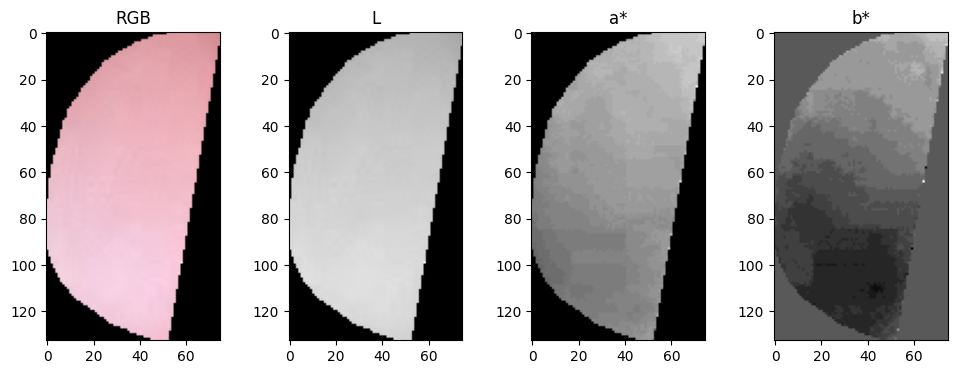

In [ ]:
import matplotlib.pyplot as plt

row = df_exp.iloc[0]

img = cv2.imread(row["path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

L,a,b = cv2.split(lab)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("RGB")

plt.subplot(1,4,2)
plt.imshow(L,cmap="gray")
plt.title("L")

plt.subplot(1,4,3)
plt.imshow(a,cmap="gray")
plt.title("a*")

plt.subplot(1,4,4)
plt.imshow(b,cmap="gray")
plt.title("b*")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Önce test %20 ayır
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Kalan %80 içinden validation %10 olacak şekilde ayır
# %10 / %80 = 0.125
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (2982, 3) (2982,)
Val  : (426, 3) (426,)
Test : (852, 3) (852,)


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "Naive Bayes": GaussianNB(var_smoothing=1e-20),
    "SVM": SVC(
    kernel="rbf",
    C=10,
    gamma="auto",
    probability=True,
    random_state=42
),
    "KNN": KNeighborsClassifier(n_neighbors=1),
    "Decision Tree": DecisionTreeClassifier(
    criterion='gini',       # veya 'entropy' – bilgi kazancına göre bölme
    max_depth=35,         # Ağacın maksimum derinliği, overfitting’i engellemek için sınır koyabilirsin
    min_samples_split=2,    # Dallanmak için gereken minimum örnek sayısı
    min_samples_leaf=2,     # Yaprakta bulunacak minimum örnek sayısı
    max_features=2,      # Bölmede kullanılacak maksimum özellik sayısı
    random_state=42
),
    "Gradient Boosting": GradientBoostingClassifier(
    n_estimators=500,        # Kaç ağaç kullanılacağı, default 100. Daha fazla → genellikle daha iyi performans
    learning_rate=0.5,      # Her ağacın katkısı, default 0.1. Küçük değer → daha stabil öğrenme
    max_depth=3,             # Ağaç derinliği, default 3. Daha derin → overfitting riski
    min_samples_split=2,     # Dallanma için minimum örnek sayısı
    min_samples_leaf=1,      # Yaprak başına minimum örnek sayısı
    subsample=0.8,           # Rastgele alt örnekleme oranı, 0.8 → overfitting azaltır
    max_features=None,       # Her ağacı oluştururken kullanılacak özellik sayısı
    random_state=42
),

  "XGBoost": XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    min_child_weight=1,
    gamma=0,
    subsample=1,
    colsample_bytree=0.95,
    reg_alpha=0,
    reg_lambda=1,
    eval_metric="logloss",
    random_state=42
),

  "CatBoost": CatBoostClassifier(
    iterations=1000,           # Kaç ağaç oluşturulacağı, default 100
    learning_rate=0.5,        # Öğrenme hızı, küçük değer → daha stabil sonuç
    depth=6,                   # Ağaç derinliği, default 6
    l2_leaf_reg=3,             # L2 regularization katsayısı
    subsample=0.8,             # Rastgele örnekleme oranı
    colsample_bylevel=0.8,     # Özellik örnekleme oranı
    verbose=0,
    random_state=42
),

  "AdaBoost": AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, min_samples_leaf=2),      # Temel öğrenici, default DecisionTreeClassifier(max_depth=1)
    n_estimators=1000,          # Kaç ağaç/estimator oluşturulacağı, default 50
    learning_rate=1,        # Her estimator’un katkı ağırlığı, default 1.0
    random_state=42
),

    "HistGradientBoosting": HistGradientBoostingClassifier(
    max_iter=100,            # Kaç boosting iterasyonu yapılacağı, default 100
    learning_rate=0.5,       # Öğrenme hızı
    max_depth=None,           # Her ağaç için maksimum derinlik, None → tam büyüme
    min_samples_leaf=20,      # Yaprak başına minimum örnek sayısı
    max_leaf_nodes=31,        # Her ağacın maksimum yaprak sayısı
    l2_regularization=0.0,    # L2 regularizasyon katsayısı
    random_state=42
)
}
cv = KFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"\n{name}")
    print("10-fold CV mean accuracy:", scores.mean())
    print("10-fold CV std:", scores.std())


Naive Bayes
10-fold CV mean accuracy: 0.5922358645148258
10-fold CV std: 0.026386835135833276

SVM
10-fold CV mean accuracy: 0.9956387062018809
10-fold CV std: 0.005209672562426428

KNN
10-fold CV mean accuracy: 0.9946319947924851
10-fold CV std: 0.004297925929481691

Decision Tree
10-fold CV mean accuracy: 0.9862505892123634
10-fold CV std: 0.007862114758862053

Gradient Boosting
10-fold CV mean accuracy: 0.9963143363785324
10-fold CV std: 0.00460395336119087

XGBoost
10-fold CV mean accuracy: 0.9939664653992054
10-fold CV std: 0.004445770581199403

CatBoost
10-fold CV mean accuracy: 0.9939664653992054
10-fold CV std: 0.0046906276235024824

AdaBoost
10-fold CV mean accuracy: 0.9943031581782675
10-fold CV std: 0.005199999763052047

HistGradientBoosting
10-fold CV mean accuracy: 0.9949720544993378
10-fold CV std: 0.0045597258327352294


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # bazı modellerde predict_proba olmayabilir
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = roc_auc_score(y_test, y_pred)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Algorithm": name,
        "Accuracy": round(acc*100,4),
        "F1-score": round(f1*100,4),
        "AUC": round(auc*100,4),
        "Precision": round(prec*100,4),
        "Recall": round(rec*100,4)
    })

results_df = pd.DataFrame(results)

results_df

,Algorithm,Accuracy,F1-score,AUC,Precision,Recall
0,Naive Bayes,59.1549,74.3363,58.9896,59.1549,100.0
1,SVM,100.0000,100.0000,100.0000,100.0000,100.0
2,KNN,100.0000,100.0000,100.0000,100.0000,100.0
3,Decision Tree,99.2958,99.4083,99.9932,98.8235,100.0
4,Gradient Boosting,100.0000,100.0000,100.0000,100.0000,100.0
5,XGBoost,100.0000,100.0000,100.0000,100.0000,100.0
6,CatBoost,99.8826,99.9009,100.0000,99.8020,100.0
7,AdaBoost,100.0000,100.0000,100.0000,100.0000,100.0
8,HistGradientBoosting,100.0000,100.0000,100.0000,100.0000,100.0


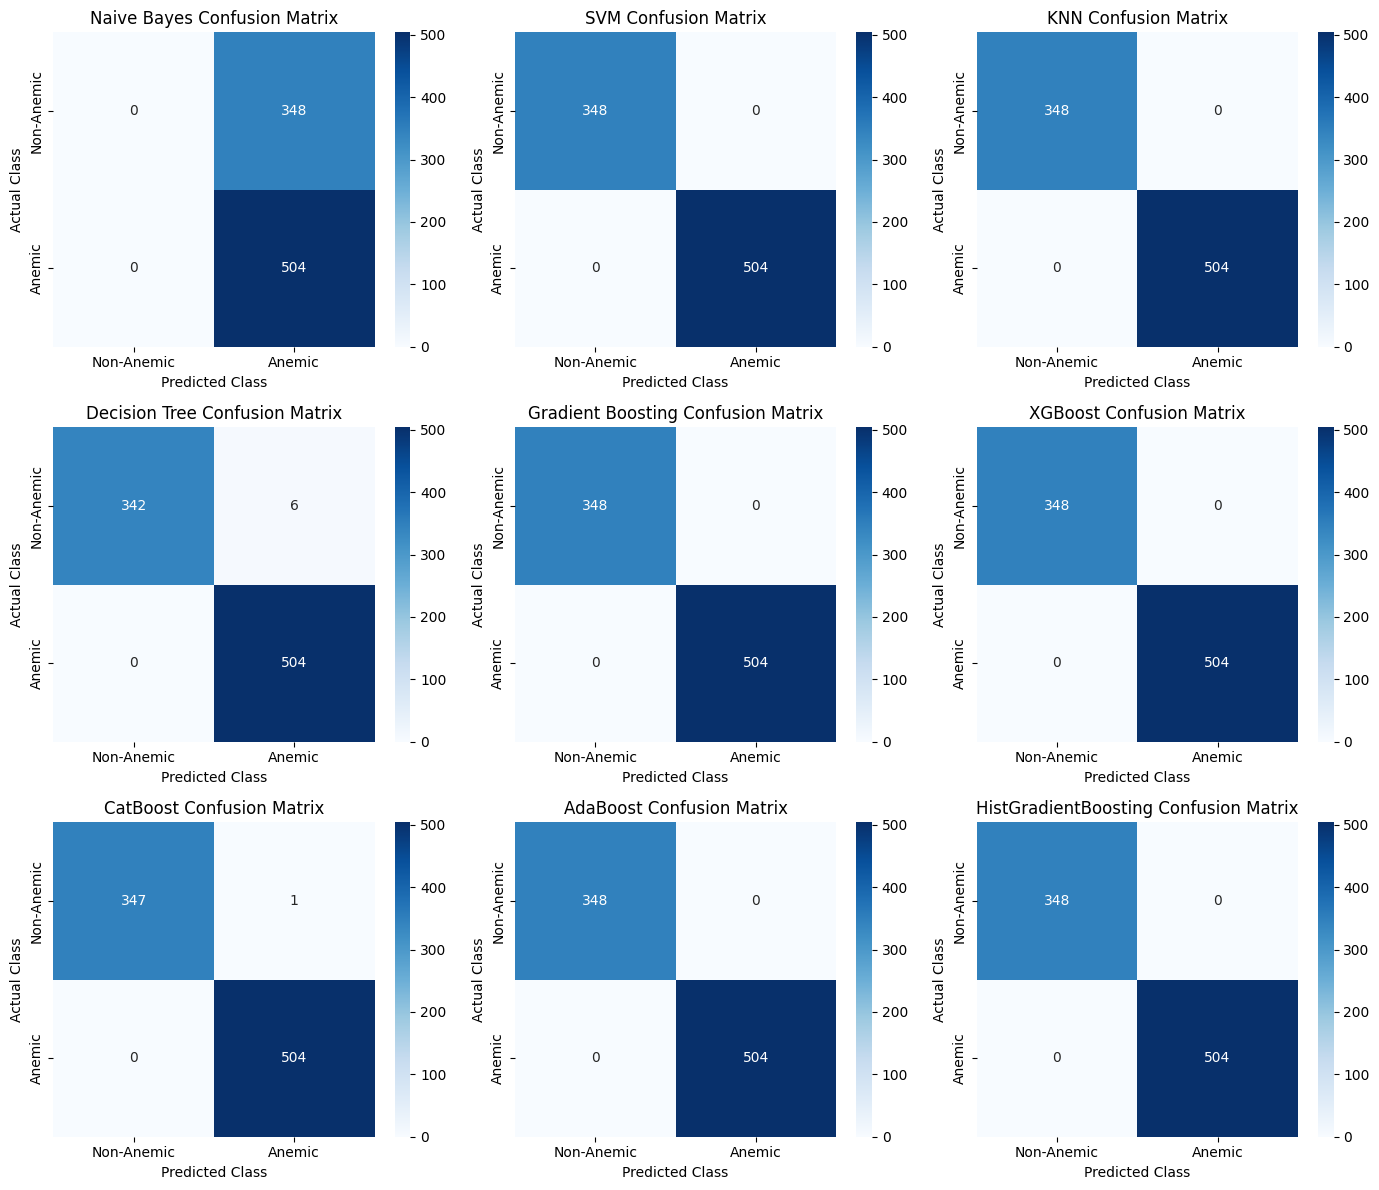

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3,3, figsize=(14,12))

axes = axes.flatten()

for i, (name,model) in enumerate(models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test,y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i],
        xticklabels=["Non-Anemic","Anemic"],
        yticklabels=["Non-Anemic","Anemic"]
    )

    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted Class")
    axes[i].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

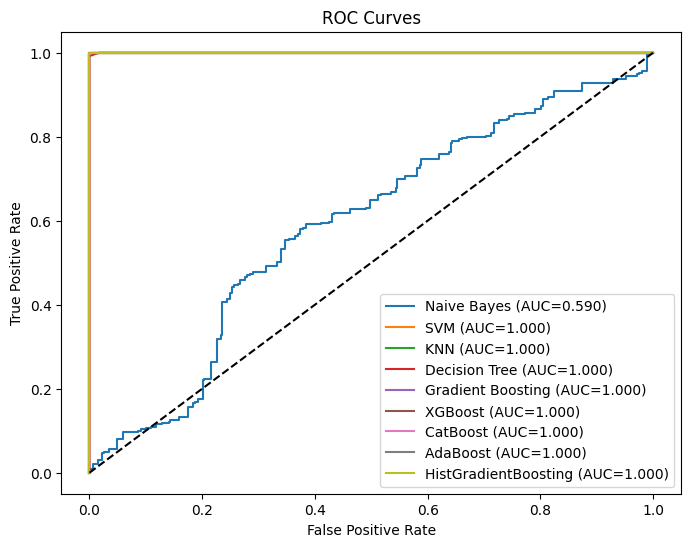

In [ ]:

from sklearn.metrics import roc_curve, auc as sk_auc

plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = sk_auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [ ]:
import joblib
import os

# Kaydedilecek klasör
model_folder = "fingernails_models"
os.makedirs(model_folder, exist_ok=True)

for name, model in models.items():
    # Modeli dosyaya kaydet
    filename = os.path.join(model_folder, f"{name.replace(' ','_')}.joblib")
    joblib.dump(model, filename)
    print(f"{name} kaydedildi → {filename}")

Naive Bayes kaydedildi → fingernails_models/Naive_Bayes.joblib
SVM kaydedildi → fingernails_models/SVM.joblib
KNN kaydedildi → fingernails_models/KNN.joblib
Decision Tree kaydedildi → fingernails_models/Decision_Tree.joblib
Gradient Boosting kaydedildi → fingernails_models/Gradient_Boosting.joblib
XGBoost kaydedildi → fingernails_models/XGBoost.joblib
CatBoost kaydedildi → fingernails_models/CatBoost.joblib
AdaBoost kaydedildi → fingernails_models/AdaBoost.joblib
HistGradientBoosting kaydedildi → fingernails_models/HistGradientBoosting.joblib



LightGBM
10-fold CV mean accuracy: 0.9963154586877959
10-fold CV std: 0.004602401455525681
  Algorithm  Accuracy  F1-score    AUC  Precision  Recall
0  LightGBM     100.0     100.0  100.0      100.0   100.0


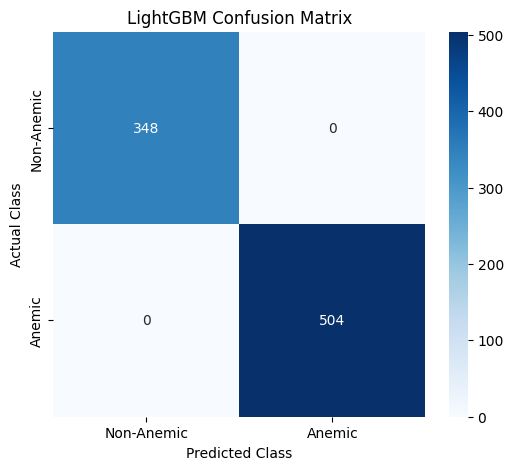

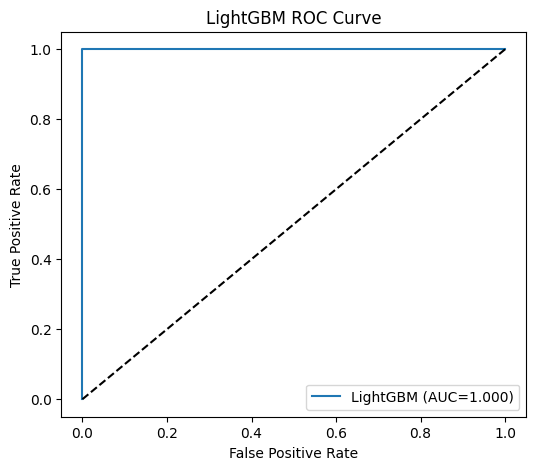

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc as sk_auc
import matplotlib.pyplot as plt
import seaborn as sns

# LightGBM için veri
X_train_lgb = pd.DataFrame(X_train, columns=["mean_a","mean_b","mean_g"])
X_test_lgb  = pd.DataFrame(X_test,  columns=["mean_a","mean_b","mean_g"])

# LightGBM modeli
lgb_model = LGBMClassifier(
    n_estimators=1000,        # Kaç ağaç oluşturulacağı, default 100
    learning_rate=0.05,       # Öğrenme hızı, küçük değer → daha stabil sonuç
    max_depth=-1,             # Maksimum ağaç derinliği, -1 → sınırsız
    num_leaves=31,            # Her ağaçta maksimum yaprak sayısı
    min_child_samples=20,     # Yaprak başına minimum örnek sayısı
    subsample=0.8,            # Rastgele örnekleme oranı
    colsample_bytree=0.8,     # Özellik örnekleme oranı
    reg_alpha=0.0,            # L1 regularizasyon
    reg_lambda=0.0,           # L2 regularizasyon
    random_state=42,
    verbose=-1
)

# 10-fold cross validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(lgb_model, X_train_lgb, y_train, cv=cv, scoring="accuracy")
print("\nLightGBM")
print("10-fold CV mean accuracy:", scores.mean())
print("10-fold CV std:", scores.std())

# Modeli train et ve test et
lgb_model.fit(X_train_lgb, y_train)
y_pred = lgb_model.predict(X_test_lgb)

# predict_proba kullanarak AUC hesapla
y_prob = lgb_model.predict_proba(X_test_lgb)[:,1]
auc = roc_auc_score(y_test, y_prob)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Sonuçları dataframe’e ekle
results_lgb = pd.DataFrame([{
    "Algorithm": "LightGBM",
    "Accuracy": round(acc*100,4),
    "F1-score": round(f1*100,4),
    "AUC": round(auc*100,4),
    "Precision": round(prec*100,4),
    "Recall": round(rec*100,4)
}])

print(results_lgb)

# LightGBM için prediction
y_pred_lgb = lgb_model.predict(X_test_lgb)
y_prob_lgb = lgb_model.predict_proba(X_test_lgb)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Anemic","Anemic"],
    yticklabels=["Non-Anemic","Anemic"]
)
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lgb)
roc_auc = sk_auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"LightGBM (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curve")
plt.legend()
plt.show()

In [ ]:
import joblib
import os

# Kaydedilecek klasör
model_folder = "fingernails_models"

# LightGBM modelini kaydet
filename = os.path.join(model_folder, "LightGBM_model.joblib")
joblib.dump(lgb_model, filename)
print(f"LightGBM modeli kaydedildi → {filename}")

LightGBM modeli kaydedildi → fingernails_models/LightGBM_model.joblib
